# Black-Scholes Model for European Option Pricing

## Overview

The Black-Scholes model is a fundamental mathematical formula in finance for calculating the theoretical price of a European option. Developed in 1973 by **Fischer Black, Myron Scholes, and Robert Merton**, this model assumes that the price of the underlying asset follows a **geometric Brownian motion**.

## Model Assumptions

- Asset price follows a log-normal distribution
- No arbitrage opportunities
- No transaction costs
- Constant and known risk-free interest rate
- Constant and known volatility


## Mathematical Formula

The price of a European call option is given by:

$$C = S_0 \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

Where:

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$$

$$d_2 = d_1 - \sigma\sqrt{T}$$

## Parameters

- **$S_0$**: Current price of the underlying asset
- **$K$**: Strike price (exercise price)
- **$r$**: Risk-free interest rate (annualized)
- **$T$**: Time to expiration (in years)
- **$\sigma$**: Volatility of the asset (annualized)
- **$N(x)$**: Cumulative distribution function of the standard normal distribution

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

Black-Scholes Formula Implementation

In [ ]:
def black_scholes_call(S, K, r, T, sigma):
    """
    Computes the price of a European call option using the Black-Scholes model.
    
    This function implements the analytical Black-Scholes formula for pricing a European
    option, which can only be exercised at the expiration date.
    
    Parameters
    ----------
    S : float
        Current spot price of the underlying asset (S₀)
    K : float
        Strike price (exercise price) of the option
    r : float
        Risk-free interest rate (annualized, e.g., 0.05 for 5%)
    T : float
        Time to expiration in years (e.g., 0.5 for 6 months)
    sigma : float
        Annualized volatility of the asset (e.g., 0.2 for 20%)
    
    Returns
    -------
    float
        The theoretical price of the European call option
    
    Examples
    --------
    >>> price = black_scholes_call(S=100, K=100, r=0.05, T=1.0, sigma=0.2)
    >>> print(f"Call option price: {price:.2f}")
    """
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*(np.sqrt(T)))
    d2 = d1 - np.sqrt(T)*sigma
    call_price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return call_price

9.294775908128095


Text(0.5, 1.0, 'Price Evolution with Volatility')

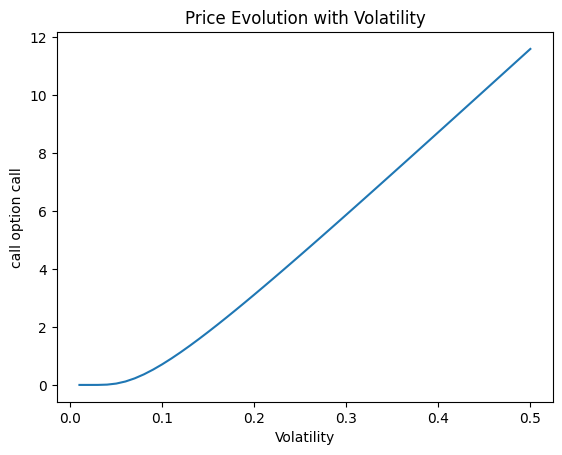

In [4]:
# Volatility Analysis
sigmas=np.linspace(0.01,0.5,50)
prices=[black_scholes_call(102,110,0.02,0.5,s) for s in sigmas]

fig,ax=plt.subplots()
ax.plot(sigmas,prices)
ax.set_xlabel('Volatility')
ax.set_ylabel('call option call')
ax.set_title('Price Evolution with Volatility')

The option price increases as volatility increases. Let's do the same analysis with time maturity.

Text(0.5, 1.0, 'Price Evolution with Time')

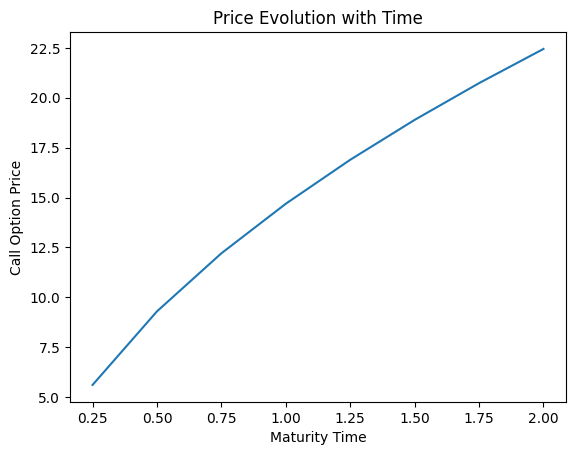

In [5]:
time=np.linspace(0.25,2,8)
prices=[black_scholes_call(102,110,0.02,t,0.42) for t in time]

fig,ax=plt.subplots()
ax.plot(time,prices)
ax.set_xlabel('Maturity Time')
ax.set_ylabel('Call Option Price')
ax.set_title('Price Evolution with Time')

Longer maturities generally lead to higher option prices due to increased uncertainty

In [ ]:
def monte_carlo_call(S, K, T, r, sigma, n_sim=10000):
    """
    Estimates the price of a European call option using Monte Carlo simulation.
    
    This numerical method simulates multiple possible trajectories of the underlying asset price
    following a geometric Brownian motion, then calculates the average discounted payoff.
    It serves as an independent validation of the analytical formula.
    
    Parameters
    ----------
    S : float
        Current spot price of the underlying asset (S₀)
    K : float
        Strike price (exercise price) of the option
    T : float
        Time to expiration in years
    r : float
        Risk-free interest rate (annualized)
    sigma : float
        Annualized volatility of the asset
    n_sim : int, optional
        Number of Monte Carlo simulations (default 10000)
        Increasing this value improves accuracy but slows computation
    
    Returns
    -------
    float
        The estimated price of the European call option
    
    Notes
    -----
    Process used: S_T = S₀ * exp((r - σ²/2)T + σ√T * Z)
    where Z ~ N(0,1) is a standard normal random variable
    
    Call payoff: max(S_T - K, 0)
    Price is the average discounted payoff: e^(-rT) * E[payoff]
    
    Examples
    --------
    >>> mc_price = monte_carlo_call(S=100, K=100, T=1.0, r=0.05, sigma=0.2, n_sim=10000)
    >>> print(f"Estimated price (Monte Carlo): {mc_price:.2f}")
    """
    Z = np.random.normal(0, 1, n_sim) 
    ST = S * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z) 
    payoff = np.maximum(ST - K, 0) 
    return np.exp(-r*T) * np.mean(payoff)

Prix Monte Carlo : 9.068575199750718


In [20]:
mc_price = monte_carlo_call(102,110,0.5,0.02,0.42)
price=black_scholes_call(102,110,0.02,0.5,0.42)
print("Black-Scholes :", price)
print("Monte Carlo  :", mc_price)

Black-Scholes : 9.294775908128095
Monte Carlo  : 9.302163851677898


The two prices are very close. This validate my implementation